## Importing Libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests 
from bs4 import BeautifulSoup
import json
from pprint import pprint
import matplotlib.image as mpimg
import matplotlib.patches as patches
from PIL import Image
from io import BytesIO
import highlight_text
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from mplsoccer import Pitch, VerticalPitch
import matplotlib.image as mpimg
import matplotlib.patches as patches
from PIL import Image
from io import BytesIO
from mplsoccer import PyPizza, add_image, FontManager
from matplotlib.patches import Rectangle
import matplotlib.font_manager as font_manager
import matplotlib.image as mpimg
import matplotlib.patches as patches
from PIL import Image
from io import BytesIO
from mplsoccer import PyPizza, add_image, FontManager
#import soccerdata as sd
import re
from unidecode import unidecode
from scipy.spatial import ConvexHull
from matplotlib.colors import LinearSegmentedColormap
from highlight_text import ax_text, fig_text
import matplotlib.patheffects as path_effects
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects


from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
#import main
#import visuals
import seaborn as sns
import requests
#import utils
import os
%load_ext autoreload
%autoreload 2

pd.set_option("display.max_rows", None, "display.max_columns", None)
background = "#010b14"
#background = "white"
text_color = 'black'
primary = '#C8102E'
secondary = 'lightblue'
mpl.rcParams['xtick.color'] = text_color
mpl.rcParams['ytick.color'] = text_color

In [2]:
import matplotlib.font_manager as fm
from mplsoccer import FontManager
base_path = '/Users/ishdeepchadha/Documents/Score/Football'
plot_path = '/Users/ishdeepchadha/Documents/Score/Plots'
# Set the path to the locally downloaded font file
font_path = f'{base_path}/Sora_Font/Sora-Regular.ttf'

# Add the font to matplotlib
font_prop = fm.FontProperties(fname=font_path)

# You can now use this font in your plots
fm_sora = FontManager()
#fm_sora.prop = font_prop

print("Font loaded and registered successfully!")

Font loaded and registered successfully!


In [3]:
import sqlite3
import pandas as pd

# Replace with your path
conn = sqlite3.connect(f'{base_path}/data extraction/score_football.db')
query = """
        SELECT *
        FROM event_data where league = 'ligue-1';
"""
df = pd.read_sql_query(query, conn)

In [4]:
df = df.drop_duplicates()

In [5]:
df['matchId'].nunique()

378

In [5]:
import pandas as pd

def tag_sequences_and_possessions_all_matches(
        df,
        match_col="matchId",
        event_col="type",
        team_col="teamName",
        outcome_col="outcomeType",
        success_values=("Successful", 1),
        time_sort_cols=("minute", "second", "index")
    ):
    """
    Adds `sequence_id` and `possession_id` *per match*.

    Parameters
    ----------
    df : pd.DataFrame
        Event feed containing one or more matches.
    match_col : str
        Column that identifies each match.
    All other parameters are identical to the single‑match function.

    Returns
    -------
    pd.DataFrame
        Same rows plus `sequence_id` and `possession_id`.
    """

    # ---------- 1. Define event buckets ----------
    CONTROLLED_EVENTS = {
        "Pass", "BallRecovery", "BallTouch", "KeeperPickup", "TakeOn",
        "Goal", "SavedShot", "Claim", "Carry", "ShotOnPost"
    }
    DEFENSIVE_EVENTS = {
        "Tackle", "Dispossessed", "Interception", "Clearance", "BlockedPass",
        "Challenge", "Aerial", "KeeperSweeper", "Punch"
    }
    STOPPAGE_EVENTS = {
        "Foul", "OffsidePass", "OffsideGiven", "OffsideProvoked",
        "Card", "Error", "CornerAwarded", "MissedShots", "ChanceMissed",
        "End", "FormationChange", "SubstitutionOn", "SubstitutionOff",
        "FormationSet", "Start"
    }

    # ---------- 2. Helper to tag ONE match ----------
    def _tag_one_match(sub):
        # Sort chronologically inside this match
        sub = sub.sort_values(list(time_sort_cols)).reset_index(drop=True)

        poss_id = -1
        seq_id  = -1
        possessing_team = None
        open_sequence   = False

        poss_ids, seq_ids = [], []

        for _, row in sub.iterrows():
            ev   = row[event_col]
            team = row[team_col]
            ok   = row[outcome_col] in success_values

            grants_control = (ev in CONTROLLED_EVENTS) and ok

            # Turnover?
            if possessing_team is not None and grants_control and team != possessing_team:
                poss_id += 1
                seq_id  += 1
                possessing_team = team
                open_sequence   = True

            # Sequence‑ending tests
            terminate = False
            if open_sequence:
                if ev in STOPPAGE_EVENTS or ev == "Goal":
                    terminate = True
                elif team != possessing_team and ev in DEFENSIVE_EVENTS:
                    terminate = True
                elif (ev in CONTROLLED_EVENTS) and not ok:
                    terminate = True

            if terminate:
                open_sequence = False
                if team != possessing_team and ev in DEFENSIVE_EVENTS:
                    possessing_team = None

            # Sequence‑start tests
            if not open_sequence and grants_control:
                if team != possessing_team:
                    poss_id += 1
                    possessing_team = team
                seq_id      += 1
                open_sequence = True

            seq_ids.append(seq_id if open_sequence else pd.NA)
            poss_ids.append(poss_id if possessing_team is not None else pd.NA)

        sub["sequence_id"]   = seq_ids
        sub["possession_id"] = poss_ids
        return sub

    # ---------- 3. Run per‑match and concatenate ----------
    out = (
        df.groupby(match_col, group_keys=False, sort=False)
          .apply(_tag_one_match)
          .reset_index(drop=True)
    )
    return out


In [6]:
poss_df = tag_sequences_and_possessions_all_matches(df)

/var/folders/1p/x285c99d20ggyt7j19j59bdm0000gn/T/ipykernel_6501/2570704420.py:104: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_tag_one_match)


In [7]:
poss_df['type'].value_counts()

type
Pass               297858
BallRecovery        26127
BallTouch           19743
Foul                14488
Clearance           13865
Aerial              13758
TakeOn              11346
Tackle              10771
CornerAwarded        5584
Dispossessed         5433
Interception         5401
Challenge            4672
BlockedPass          4497
SavedShot            3853
Save                 3802
KeeperPickup         3428
SubstitutionOff      2606
SubstitutionOn       2606
MissedShots          2562
End                  1788
Card                 1230
Start                1192
OffsideProvoked       968
OffsideGiven          968
OffsidePass           968
Goal                  888
FormationChange       710
FormationSet          596
Claim                 521
Error                 355
ShieldBallOpp         313
KeeperSweeper         269
ShotOnPost            161
Punch                 160
PenaltyFaced          116
Smother                77
GoodSkill              37
ChanceMissed            7
CrossNo

In [39]:
def possession_share_by_time(
    df,
    team_col="teamName",
    poss_col="possession_id",
    time_col="cumulative_mins",
    sort_cols=["possession_id", "index"]
):
    """
    Calculate each team’s possession percentage weighted by time (in minutes).

    Parameters
    ----------
    df : pd.DataFrame
        Event data tagged with `possession_id`.
    team_col : str
        Column that holds team names or IDs.
    poss_col : str
        Column that identifies possession chunks.
    time_col : str
        Timestamp column (in minutes, ideally continuous, like `cumulative_mins`).
    sort_cols : list
        Sort priority for determining start/end of each possession.

    Returns
    -------
    pd.DataFrame
        Columns: team, possession_time, possession_pct
    """

    # 1. Keep only rows with valid possession and time
    df_valid = df.dropna(subset=[poss_col, team_col, time_col]).copy()

    # 2. For each possession, get: team, start_time, end_time
    poss_df = (
        df_valid.sort_values(sort_cols)
                .groupby(poss_col)
                .agg(
                    team=(team_col, 'first'),
                    start_time=(time_col, 'first'),
                    end_time=(time_col, 'last')
                )
                .reset_index()
    )
    poss_df["duration"] = poss_df["end_time"] - poss_df["start_time"]

    # 3. Remove negative durations (bad data or errors)
    poss_df = poss_df[poss_df["duration"] >= 0]

    # 4. Sum duration per team
    team_times = (
        poss_df.groupby("team")["duration"]
               .sum()
               .rename("possession_time")
               .reset_index()
    )

    # 5. Compute time-weighted percentage
    total_time = team_times["possession_time"].sum()
    team_times["possession_pct"] = 100 * team_times["possession_time"] / total_time

    return team_times.sort_values("possession_pct", ascending=False).reset_index(drop=True)


In [40]:
possession_summary = possession_share_by_time(poss_df)
print(possession_summary)

      team  possession_time  possession_pct
0      PSG        50.250000       60.408736
1  Chelsea        32.933333       39.591264


In [49]:
print(list(poss_df.columns))

['index', 'eventId', 'minute', 'second', 'teamId', 'x', 'y', 'expandedMinute', 'period', 'type', 'outcomeType', 'qualifiers', 'satisfiedEventsTypes', 'isTouch', 'playerId', 'endX', 'endY', 'blockedX', 'blockedY', 'goalMouthZ', 'goalMouthY', 'isShot', 'relatedEventId', 'relatedPlayerId', 'isGoal', 'cardType', 'isOwnGoal', 'cumulative_mins', 'playerName', 'Unnamed: 0_x', 'h_a', 'matchId', 'startDate', 'startTime', 'score', 'ftScore', 'htScore', 'etScore', 'venueName', 'maxMinute', 'shotBodyType', 'situation', 'shotSixYardBox', 'shotPenaltyArea', 'shotOboxTotal', 'shotOpenPlay', 'shotCounter', 'shotSetPiece', 'shotDirectCorner', 'shotOffTarget', 'shotOnPost', 'shotOnTarget', 'shotsTotal', 'shotBlocked', 'shotRightFoot', 'shotLeftFoot', 'shotHead', 'shotObp', 'goalSixYardBox', 'goalPenaltyArea', 'goalObox', 'goalOpenPlay', 'goalCounter', 'goalSetPiece', 'penaltyScored', 'goalOwn', 'goalNormal', 'goalRightFoot', 'goalLeftFoot', 'goalHead', 'goalObp', 'shortPassInaccurate', 'shortPassAccurat

## Model

In [24]:
# Load EPV grid (32x22 → standard pitch format)
epv_grid = pd.read_csv("EPV_grid.csv", index_col=0).values  # shape (22, 32)
pitch_x_bins, pitch_y_bins = 32, 22

def get_epv_value(x, y):
    if np.isnan(x) or np.isnan(y):
        return 0.0
    x_bin = min(int(x / (100 / pitch_x_bins)), pitch_x_bins - 1)
    y_bin = min(int(y / (100 / pitch_y_bins)), pitch_y_bins - 1)
    return epv_grid[y_bin][x_bin]

poss_df["start_epv"] = poss_df.apply(lambda row: get_epv_value(row["x"], row["y"]), axis=1)
poss_df["end_epv"]   = poss_df.apply(lambda row: get_epv_value(row["endX"], row["endY"]), axis=1)
poss_df["epv_added"] = poss_df["end_epv"] - poss_df["start_epv"]

poss_df["xg_chain"] = poss_df.groupby("possession_id")["xG"].transform("max").fillna(0)

poss_df["dynamic_epv"] = (
    0.5 * poss_df["epv_added"].fillna(0) +   # spatial threat
    0.3 * poss_df["xT"].fillna(0) +          # threat added via movement
    0.1 * poss_df["xA"].fillna(0) +          # chance creation
    0.1 * poss_df["xg_chain"].fillna(0)      # eventual shot value
)


In [25]:
team_df = poss_df[(poss_df['playerName'] != 'nan')].copy()
# Step 1: Identify subOn and subOff minutes per player per match
sub_on = team_df[team_df['subOn'] == True].groupby(['playerName', 'matchId'])['minute'].min().reset_index().rename(columns={'minute': 'subOnMinute'})
sub_off = team_df[team_df['subOff'] == True].groupby(['playerName', 'matchId'])['minute'].min().reset_index().rename(columns={'minute': 'subOffMinute'})

# Step 2: Get match full length
match_lengths = team_df.groupby('matchId')['maxMinute'].max().reset_index().rename(columns={'maxMinute': 'matchLength'})

# Step 3: Build player-match records
player_match = team_df[['playerName', 'matchId']].drop_duplicates()
player_match = player_match.merge(sub_on, on=['playerName', 'matchId'], how='left')
player_match = player_match.merge(sub_off, on=['playerName', 'matchId'], how='left')
player_match = player_match.merge(match_lengths, on='matchId', how='left')

# Step 4: Calculate minutes played
def calc_minutes(row):
    if pd.notna(row['subOnMinute']) and pd.notna(row['subOffMinute']):
        return row['subOffMinute'] - row['subOnMinute']
    elif pd.notna(row['subOnMinute']):
        return row['matchLength'] - row['subOnMinute']
    elif pd.notna(row['subOffMinute']):
        return row['subOffMinute']
    else:
        return row['matchLength']

player_match['minutesPlayed'] = player_match.apply(calc_minutes, axis=1)

# Step 5: Sum across all matches per player
total_minutes_played = player_match.groupby('playerName')['minutesPlayed'].sum().reset_index().rename(columns={'minutesPlayed': 'TotalMinutesPlayed'})

team_df = team_df.merge(total_minutes_played,on='playerName',how='left')
team_df = team_df[team_df['TotalMinutesPlayed'] > 2000].copy()

In [28]:
team_df.head()

,index,eventId,minute,second,teamId,x,y,expandedMinute,period,type,outcomeType,qualifiers,satisfiedEventsTypes,isTouch,playerId,endX,endY,blockedX,blockedY,goalMouthZ,goalMouthY,isShot,relatedEventId,relatedPlayerId,isGoal,cardType,isOwnGoal,cumulative_mins,playerName,Unnamed: 0_x,h_a,matchId,startDate,startTime,score,ftScore,htScore,etScore,venueName,maxMinute,shotBodyType,situation,shotSixYardBox,shotPenaltyArea,shotOboxTotal,shotOpenPlay,shotCounter,shotSetPiece,shotDirectCorner,shotOffTarget,shotOnPost,shotOnTarget,shotsTotal,shotBlocked,shotRightFoot,shotLeftFoot,shotHead,shotObp,goalSixYardBox,goalPenaltyArea,goalObox,goalOpenPlay,goalCounter,goalSetPiece,penaltyScored,goalOwn,goalNormal,goalRightFoot,goalLeftFoot,goalHead,goalObp,shortPassInaccurate,shortPassAccurate,passCorner,passCornerAccurate,passCornerInaccurate,passFreekick,passBack,passForward,passLeft,passRight,keyPassLong,keyPassShort,keyPassCross,keyPassCorner,keyPassThroughball,keyPassFreekick,keyPassThrowin,keyPassOther,assistCross,assistCorner,assistThroughball,assistFreekick,assistThrowin,assistOther,dribbleLost,dribbleWon,challengeLost,interceptionWon,clearanceHead,outfielderBlock,passCrossBlockedDefensive,outfielderBlockedPass,offsideGiven,offsideProvoked,foulGiven,foulCommitted,yellowCard,voidYellowCard,secondYellow,redCard,turnover,dispossessed,saveLowLeft,saveHighLeft,saveLowCentre,saveHighCentre,saveLowRight,saveHighRight,saveHands,saveFeet,saveObp,saveSixYardBox,savePenaltyArea,saveObox,keeperDivingSave,standingSave,closeMissHigh,closeMissHighLeft,closeMissHighRight,closeMissLeft,closeMissRight,shotOffTargetInsideBox,touches,assist,ballRecovery,clearanceEffective,clearanceTotal,clearanceOffTheLine,dribbleLastman,errorLeadsToGoal,errorLeadsToShot,intentionalAssist,interceptionAll,interceptionIntheBox,keeperClaimHighLost,keeperClaimHighWon,keeperClaimLost,keeperClaimWon,keeperOneToOneWon,parriedDanger,parriedSafe,collected,keeperPenaltySaved,keeperSaveInTheBox,keeperSaveTotal,keeperSmother,keeperSweeperLost,keeperMissed,passAccurate,passBackZoneInaccurate,passForwardZoneAccurate,passInaccurate,passAccuracy,cornerAwarded,passKey,passChipped,passCrossAccurate,passCrossInaccurate,passLongBallAccurate,passLongBallInaccurate,passThroughBallAccurate,passThroughBallInaccurate,passThroughBallInacurate,passFreekickAccurate,passFreekickInaccurate,penaltyConceded,penaltyMissed,penaltyWon,passRightFoot,passLeftFoot,passHead,sixYardBlock,tackleLastMan,tackleLost,tackleWon,cleanSheetGK,cleanSheetDL,cleanSheetDC,cleanSheetDR,cleanSheetDML,cleanSheetDMC,cleanSheetDMR,cleanSheetML,cleanSheetMC,cleanSheetMR,cleanSheetAML,cleanSheetAMC,cleanSheetAMR,cleanSheetFWL,cleanSheetFW,cleanSheetFWR,cleanSheetSub,goalConcededByTeamGK,goalConcededByTeamDL,goalConcededByTeamDC,goalConcededByTeamDR,goalConcededByTeamDML,goalConcededByTeamDMC,goalConcededByTeamDMR,goalConcededByTeamML,goalConcededByTeamMC,goalConcededByTeamMR,goalConcededByTeamAML,goalConcededByTeamAMC,goalConcededByTeamAMR,goalConcededByTeamFWL,goalConcededByTeamFW,goalConcededByTeamFWR,goalConcededByTeamSub,goalConcededOutsideBoxGoalkeeper,goalScoredByTeamGK,goalScoredByTeamDL,goalScoredByTeamDC,goalScoredByTeamDR,goalScoredByTeamDML,goalScoredByTeamDMC,goalScoredByTeamDMR,goalScoredByTeamML,goalScoredByTeamMC,goalScoredByTeamMR,goalScoredByTeamAML,goalScoredByTeamAMC,goalScoredByTeamAMR,goalScoredByTeamFWL,goalScoredByTeamFW,goalScoredByTeamFWR,goalScoredByTeamSub,aerialSuccess,duelAerialWon,duelAerialLost,offensiveDuel,defensiveDuel,bigChanceMissed,bigChanceScored,bigChanceCreated,overrun,successfulFinalThirdPasses,punches,penaltyShootoutScored,penaltyShootoutMissedOffTarget,penaltyShootoutSaved,penaltyShootoutSavedGK,penaltyShootoutConcededGK,throwIn,subOn,subOff,defensiveThird,midThird,finalThird,pos,Unnamed: 0_y,x1_bin_xT,y1_bin_xT,x2_bin_xT,y2_bin_xT,start_zone_value_xT,end_zone_value_xT,xT,teamName,prog_pass,prog_carry,pass_or_carry_angle,xA,xG,league,country,season,sequence_id,possession_id,start_epv,end_ep

In [29]:
# ─────────────────────────────────────────────────────────────────────
# 1. EVENT-LEVEL CLASSIFICATION (FIXED)
# ─────────────────────────────────────────────────────────────────────
team_df["is_progressive"] = team_df["dynamic_epv"] >= 0.05
team_df["is_regressive"]  = team_df["dynamic_epv"] < 0.05

# Fix the loss condition — we want Unsuccessful/Dispossessed
team_df["loss_of_possession"] = (
    (team_df["type"] == "Dispossessed") |
    ((team_df["type"] == "BallTouch") & (team_df["outcomeType"] == "Unsuccessful"))
)
team_df["loss_direct_threat"] = team_df["loss_of_possession"] & (team_df["x"] > 75)

# Value contributions per category
team_df["pv_progressive"]   = team_df["dynamic_epv"].where(team_df["is_progressive"], 0)
team_df["pv_regressive"]    = team_df["dynamic_epv"].where(team_df["is_regressive"], 0)
team_df["pv_loss"]          = team_df["dynamic_epv"].where(team_df["loss_of_possession"], 0)
team_df["pv_loss_direct"]   = team_df["dynamic_epv"].where(team_df["loss_direct_threat"], 0)

# Count progressive actions
team_df["progressive_action"] = team_df["is_progressive"].astype(int)

# ─────────────────────────────────────────────────────────────────────
# 2. PLAYER-LEVEL AGGREGATION
# ─────────────────────────────────────────────────────────────────────
player_pv = team_df.groupby("playerName").agg({
    "pv_progressive": "sum",
    "pv_regressive": "sum",
    "pv_loss": "sum",
    "pv_loss_direct": "sum",
    "dynamic_epv": "sum",
    "TotalMinutesPlayed": "first",
    "progressive_action": "sum"
}).rename(columns={"TotalMinutesPlayed": "minutesPlayed"})

# Per 90 normalization
player_pv["pv_progressive_per90"]  = player_pv["pv_progressive"] / player_pv["minutesPlayed"] * 90
player_pv["pv_regressive_per90"]   = player_pv["pv_regressive"] / player_pv["minutesPlayed"] * 90
player_pv["pv_loss_per90"]         = player_pv["pv_loss"] / player_pv["minutesPlayed"] * 90
player_pv["pv_loss_direct_per90"]  = player_pv["pv_loss_direct"] / player_pv["minutesPlayed"] * 90
player_pv["net_pv_per90"] = (
    player_pv["pv_progressive_per90"]
    - player_pv["pv_regressive_per90"]
    - player_pv["pv_loss_per90"]
    - player_pv["pv_loss_direct_per90"]
)

# PV quality: avg PV per progressive action
player_pv["pv_per_prog_action"] = player_pv["pv_progressive"] / player_pv["progressive_action"].replace(0, np.nan)

player_pv['passes_per_90'] = team_df[team_df['passAccurate'] == True].groupby(team_df['playerName']).size() \
                                .div(player_pv['minutesPlayed']) * 90

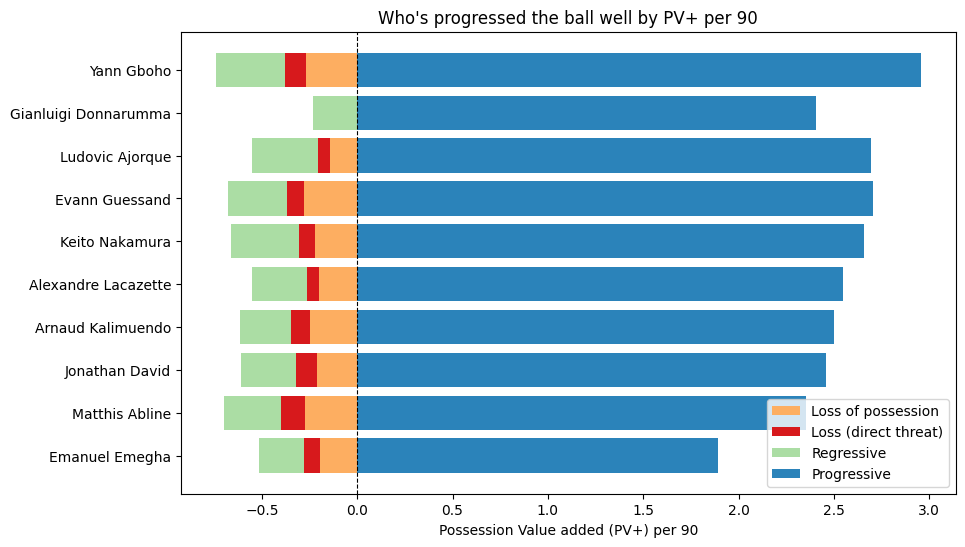

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Select top 10 players by net PV
plot_df = player_pv.sort_values("net_pv_per90", ascending=True).head(10)

# Data to plot
players = plot_df.index.tolist()
progressive = plot_df["pv_progressive_per90"].values
regressive = plot_df["pv_regressive_per90"].abs().values
loss = plot_df["pv_loss_per90"].abs().values
loss_direct = plot_df["pv_loss_direct_per90"].abs().values

# Bar positions
y_pos = np.arange(len(players))

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Stack negative values first (losses)
ax.barh(y_pos, -loss, color="#fdae61", label="Loss of possession")
ax.barh(y_pos, -loss_direct, left=-loss, color="#d7191c", label="Loss (direct threat)")
ax.barh(y_pos, -regressive, left=-loss-loss_direct, color="#abdda4", label="Regressive")

# Now positive (progressive)
ax.barh(y_pos, progressive, color="#2b83ba", label="Progressive")

# Labels and style
ax.set_yticks(y_pos)
ax.set_yticklabels(players)
ax.set_xlabel("Possession Value added (PV+) per 90")
ax.set_title("Who's progressed the ball well by PV+ per 90")
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Legend
ax.legend(loc="best")

#plt.savefig(f'{plot_path}/EPV/Barcelona.png',dpi=500,bbox_inches = 'tight',facecolor=background)


In [115]:
player_pv.head()

,pv_progressive,pv_regressive,pv_loss,pv_loss_direct,dynamic_epv,minutesPlayed,progressive_action,pv_progressive_per90,pv_regressive_per90,pv_loss_per90,pv_loss_direct_per90,net_pv_per90,pv_per_prog_action,passes_per_90
playerName,,,,,,,,,,,,,,
Aaron Martin,39.451358,1.328335,2.790746,0.592587,195.213442,3078.0,366,1.153548,0.038840,0.081601,0.017327,1.015780,0.107791,25.994152
Aaron Ramsdale,44.038395,2.240647,0.375990,0.000000,160.029505,2896.0,429,1.368597,0.069633,0.011685,0.000000,1.287278,0.102654,20.946133
Aaron Wan-Bissaka,47.246205,2.538601,4.304054,0.967280,234.375850,3282.0,456,1.295600,0.069614,0.118027,0.026525,1.081433,0.103610,33.619744
Abde Ezzalzouli,12.985433,2.772531,8.760255,3.720905,126.302612,2052.0,123,0.569537,0.121602,0.384222,0.163198,-0.099485,0.105573,23.026316
Abdel Abqar,25.585647,2.006927,1.830684,0.340174,135.735817,2617.0,250,0.879904,0.069019,0.062958,0.011699,0.736228,0.102343,24.451662


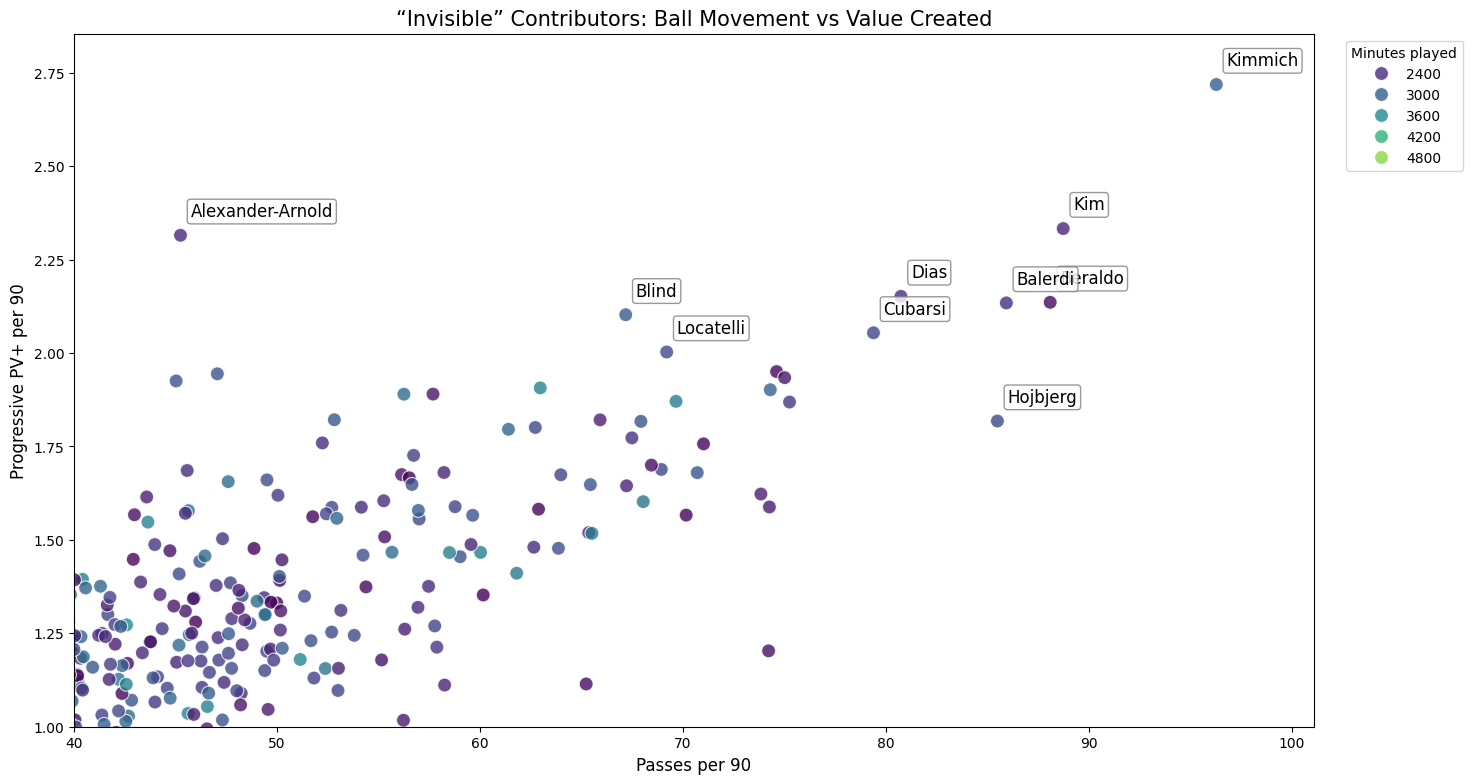

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── CONFIG ─────────────────────────────────────────────────────────
X_MIN = 40          # passes/90 lower bound
Y_MIN = 1          # PV lower bound
LABEL_X_PAD = 0.5   # text offset in x
LABEL_Y_PAD = 0.05  # text offset in y

# ── SCATTER PLOT ───────────────────────────────────────────────────
plt.figure(figsize=(16, 9))
scatter = sns.scatterplot(
    data=player_pv,
    x='passes_per_90',
    y='pv_progressive_per90',
    hue='minutesPlayed',      # colour‑scale by minutes
    palette='viridis',
    s=100,
    alpha=0.8
)

# Mean reference lines
x_mean = player_pv['passes_per_90'].mean()
y_mean = player_pv['pv_progressive_per90'].mean()
#plt.axhline(y_mean, linestyle='--', color='gray', linewidth=0.8)
#plt.axvline(x_mean, linestyle='--', color='gray', linewidth=0.8)

# Annotate standout players  (passes > 80  OR  PV > 2)
for _, row in player_pv.iterrows():
    if row['passes_per_90'] > 80 or row['pv_progressive_per90'] > 2:
        # Grab the player’s full name safely
        name = row.get('playerName', str(_))          # fallback to index if column missing
        last = name.split(' ')[-1] if ' ' in name else name
        plt.text(row['passes_per_90'] + LABEL_X_PAD,
                 row['pv_progressive_per90'] + LABEL_Y_PAD,
                 last,
                 fontsize=12,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.8))

# Axis limits  (x ≥ 40, y ≥ 0)
plt.xlim(X_MIN, player_pv['passes_per_90'].max() * 1.05)
plt.ylim(Y_MIN, player_pv['pv_progressive_per90'].max() * 1.05)

# Labels & title
plt.xlabel("Passes per 90",fontsize=12)
plt.ylabel("Progressive PV+ per 90",fontsize=12)
plt.title("“Invisible” Contributors: Ball Movement vs Value Created",fontsize=15)

# Legend tweaks
plt.legend(title="Minutes played", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.savefig(f'{plot_path}/EPV/PassesP90VsPV.png',dpi=500,bbox_inches = 'tight',facecolor=background)


In [206]:
player_pv.head()

,pv_progressive,pv_regressive,pv_loss,pv_loss_direct,dynamic_epv,minutesPlayed,progressive_action,pv_progressive_per90,pv_regressive_per90,pv_loss_per90,pv_loss_direct_per90,net_pv_per90,pv_per_prog_action,passes_per_90
playerName,,,,,,,,,,,,,,
Aaron Martin,39.451358,1.328335,2.790746,0.592587,195.213442,3078.0,366,1.153548,0.038840,0.081601,0.017327,1.015780,0.107791,25.994152
Aaron Ramsdale,44.038395,2.240647,0.375990,0.000000,160.029505,2896.0,429,1.368597,0.069633,0.011685,0.000000,1.287278,0.102654,20.946133
Aaron Wan-Bissaka,47.246205,2.538601,4.304054,0.967280,234.375850,3282.0,456,1.295600,0.069614,0.118027,0.026525,1.081433,0.103610,33.619744
Abde Ezzalzouli,12.985433,2.772531,8.760255,3.720905,126.302612,2052.0,123,0.569537,0.121602,0.384222,0.163198,-0.099485,0.105573,23.026316
Abdel Abqar,25.585647,2.006927,1.830684,0.340174,135.735817,2617.0,250,0.879904,0.069019,0.062958,0.011699,0.736228,0.102343,24.451662


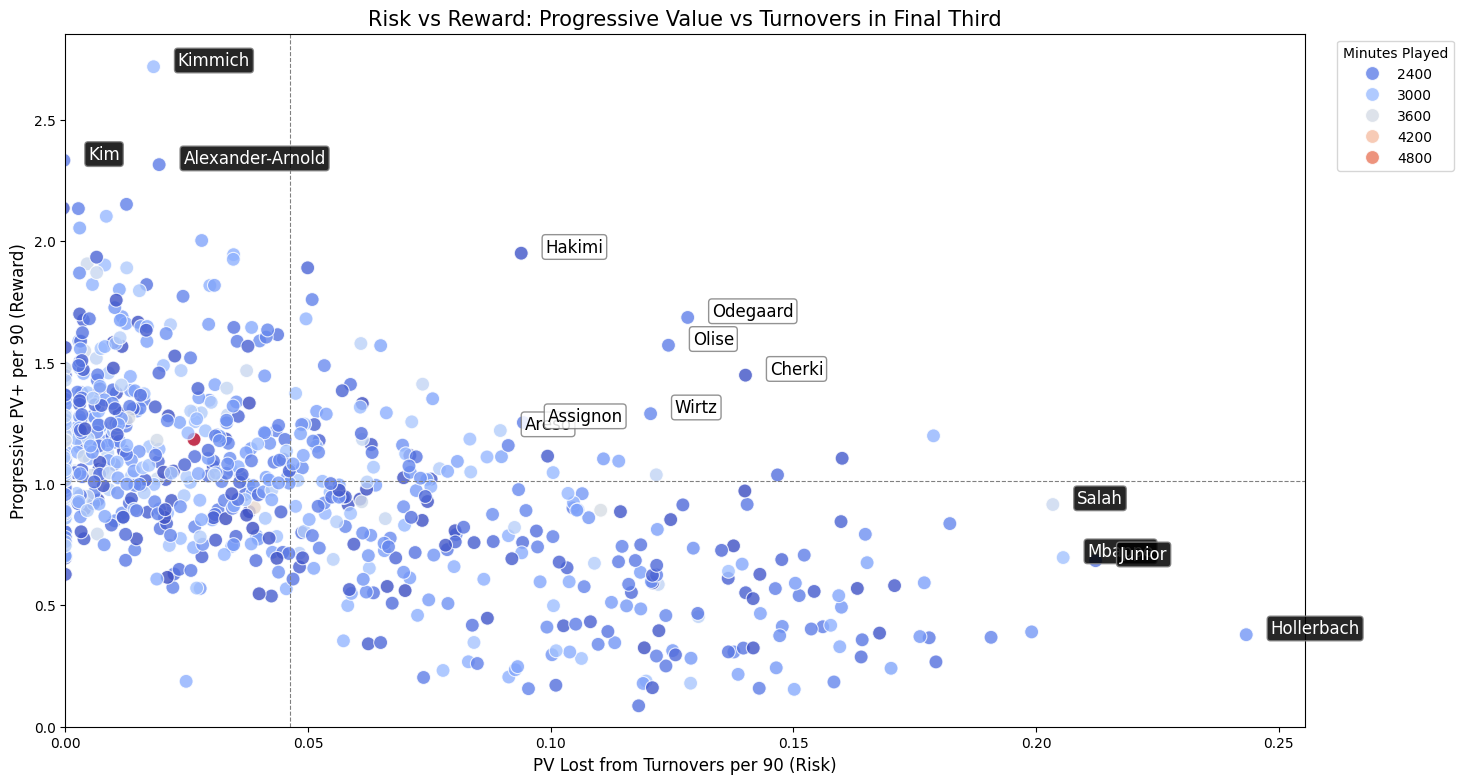

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up figure
plt.figure(figsize=(16, 9))

# Scatter plot
sns.scatterplot(
    data=player_pv,
    x='pv_loss_direct_per90',
    y='pv_progressive_per90',
    hue='minutesPlayed',
    palette='coolwarm',
    s=100,
    alpha=0.8
)

# Plot averages
x_mean = player_pv['pv_loss_direct_per90'].mean()
y_mean = player_pv['pv_progressive_per90'].mean()
plt.axhline(y_mean, linestyle='--', color='gray', linewidth=0.8)
plt.axvline(x_mean, linestyle='--', color='gray', linewidth=0.8)

# Annotate standout players
for _, row in player_pv.iterrows():
    name = row.get('playerName', str(_))
    last = name.split(' ')[-1] if ' ' in name else name
    if row['pv_progressive_per90'] > 1.2 and row['pv_loss_direct_per90'] > 0.085:
        plt.text(
            row['pv_loss_direct_per90']+0.005,
            row['pv_progressive_per90']+0.005,
            last,
            fontsize=12,
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.85)
        )
    elif row['pv_progressive_per90'] > 2.2 or row['pv_loss_direct_per90'] > 0.2:
        plt.text(
            row['pv_loss_direct_per90']+0.005,
            row['pv_progressive_per90']+0.005,
            last,
            fontsize=12,
            color='white',
            bbox=dict(facecolor='black', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.85)
        )

# Axis limits (optional tuning)
plt.xlim(0, player_pv['pv_loss_direct_per90'].max() * 1.05)
plt.ylim(0, player_pv['pv_progressive_per90'].max() * 1.05)

# Labels
plt.xlabel("PV Lost from Turnovers per 90 (Risk)",fontsize=12)
plt.ylabel("Progressive PV+ per 90 (Reward)",fontsize=12)
plt.title("Risk vs Reward: Progressive Value vs Turnovers in Final Third",fontsize=15)

# Legend
plt.legend(title="Minutes Played", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.savefig(f'{plot_path}/EPV/RiskVReward.png',dpi=500,bbox_inches = 'tight',facecolor=background)


In [163]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Calculate basic pass metrics
poss_df["pass_length"] = np.sqrt((poss_df["endX"] - poss_df["x"])**2 + (poss_df["endY"] - poss_df["y"])**2)
poss_df["pass_angle"] = np.arctan2(poss_df["endY"] - poss_df["y"], poss_df["endX"] - poss_df["x"])

# Sort before grouping
poss_df = poss_df.sort_values(['teamName', 'matchId', 'possession_id', 'minute'])

# Aggregate possession-level features (select a compact subset for clustering)
features_to_agg = {
    "pass_length": ["mean", "std", "max"],
    "pass_angle": "std",
    "passKey": "sum",
    "shotsTotal": "sum",
    "goalOpenPlay": "sum",
    "bigChanceCreated": "sum",
    "turnover": "sum",
    "dispossessed": "sum",
    "dribbleWon": "sum",
    "dribbleLost": "sum",
    "interceptionWon": "sum",
    "keyPassThroughball": "sum",
    "assistThroughball": "sum",
    "prog_pass": "sum",
    "prog_carry": "sum",
    "x": "first",
    "endX": "last",
    "y": "first",
    "endY": "last"
}

poss_summary = poss_df.groupby(["teamName", "matchId", "possession_id"]).agg(features_to_agg)
poss_summary.columns = ['_'.join(col) for col in poss_summary.columns]
poss_summary = poss_summary.reset_index()

# Calculate net progression
poss_summary['net_x'] = poss_summary['endX_last'] - poss_summary['x_first']
poss_summary['net_y'] = poss_summary['endY_last'] - poss_summary['y_first']

# Feature selection for clustering
cluster_features = [
    'pass_length_mean', 'pass_length_std', 'pass_length_max',
    'pass_angle_std', 'passKey_sum', 'shotsTotal_sum',
    'goalOpenPlay_sum', 'bigChanceCreated_sum', 'turnover_sum',
    'dispossessed_sum', 'dribbleWon_sum', 'dribbleLost_sum',
    'interceptionWon_sum', 'keyPassThroughball_sum',
    'assistThroughball_sum', 'prog_pass_sum', 'prog_carry_sum',
    'net_x', 'net_y'
]

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(poss_summary[cluster_features].fillna(0))


# KMeans Clustering
kmeans = KMeans(n_clusters=6, random_state=42)
poss_summary["pattern"] = kmeans.fit_predict(X)

# Optional: Map pattern numbers to readable names (based on inspection)
pattern_labels = {
    0: "Direct Play",
    1: "Short Progression",
    2: "Overload & Switch",
    3: "Lateral Circulation",
    4: "Slow Build‑Up",
    5: "Long Progression"
}
poss_summary["pattern"] = poss_summary["pattern"].map(pattern_labels)

# Merge pattern labels back into main DataFrame
poss_df = poss_df.merge(
    poss_summary[["teamName", "matchId", "possession_id", "pattern"]],
    on=["teamName", "matchId", "possession_id"],
    how="left"
)

# ─────────────────────────────────────────────────────────────────────────
# 1.  MAP EACH PATTERN TO A CLUSTER
# ─────────────────────────────────────────────────────────────────────────
cluster_map = {
    "Short Progression":      "Build‑Up",
    "Slow Build‑Up":          "Build‑Up",
    "Lateral Circulation":    "Build‑Up",
    "Overload & Switch":      "Build‑Up",
    "Long Progression":       "Penetration",
    "Direct Play":            "Chance Creation"
}
# Merge classified patterns back into poss_df
poss_df["cluster"] = poss_df["pattern"].map(cluster_map).fillna("Other")

# ─────────────────────────────────────────────────────────────────────────
# 2.  BUILD POSSESSION‑LEVEL TABLE  (xPV, team, cluster)
# ─────────────────────────────────────────────────────────────────────────
chain_epv = (
    poss_df.groupby(["teamName", "matchId", "possession_id"])
           ["dynamic_epv"].sum()
           .reset_index(name="chain_xPV")
)

chain_epv = chain_epv.merge(
    poss_df[["teamName", "matchId", "possession_id", "pattern", "cluster"]].drop_duplicates(),
    on=["teamName", "matchId", "possession_id"],
    how="left"
)

# ─────────────────────────────────────────────────────────────────────────
# 3.  AGGREGATE xPV PER TEAM & CLUSTER
# ─────────────────────────────────────────────────────────────────────────
team_cluster_totals = (
    chain_epv.groupby(["cluster", "teamName"])
             ["chain_xPV"].sum()
             .reset_index()
             .rename(columns={"chain_xPV": "Total_xPV"})
)

# ─────────────────────────────────────────────────────────────────────────
# 4.  FIND BEST TEAM IN EACH CLUSTER
# ─────────────────────────────────────────────────────────────────────────
best_teams = (
    team_cluster_totals.loc[team_cluster_totals.groupby("cluster")["Total_xPV"].idxmax()]
    .reset_index(drop=True)
)

# ─────────────────────────────────────────────────────────────────────────
# 5.  FOR EACH (cluster, best‑team) FIND MOST IMPORTANT PLAYER
# ─────────────────────────────────────────────────────────────────────────
records = []

for _, row in best_teams.iterrows():
    cl  = row["cluster"]
    t   = row["teamName"]

    # Possessions by that team in that cluster
    poss_ids = chain_epv.loc[
        (chain_epv["cluster"] == cl) & (chain_epv["teamName"] == t),
        ["matchId", "possession_id"]
    ]

    merged = poss_df.merge(poss_ids, on=["matchId", "possession_id"], how="inner")
    player_tot = (
        merged.groupby("playerName")["dynamic_epv"]
              .sum()
              .reset_index()
              .sort_values("dynamic_epv", ascending=False)
    )

    best_player, best_player_xpv = player_tot.iloc[0]["playerName"], player_tot.iloc[0]["dynamic_epv"]

    records.append({
        "Pattern Cluster": cl,
        "Top Team": t,
        "Team Agg xPV": round(row["Total_xPV"], 2),
        "Key Player": best_player,
        "Player xPV": round(best_player_xpv, 2)
    })

summary_tables = pd.DataFrame(records).sort_values("Pattern Cluster").reset_index(drop=True)

print("\n=== MOST DANGEROUS PATTERNS BY CLUSTER ===")
print(summary_tables.to_string(index=False))


/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-pac


=== MOST DANGEROUS PATTERNS BY CLUSTER ===
Pattern Cluster      Top Team  Team Agg xPV        Key Player  Player xPV
       Build‑Up     Tottenham        924.65       Pedro Porro       79.25
Chance Creation   Real Madrid       1811.04 Federico Valverde      159.55
    Penetration Bayern Munich        509.25    Joshua Kimmich       65.94


In [164]:
pip install matplotlib-venn


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=93584ad0118aa7a8fc4723031193ab50ed2cdf192a9816b5a91ffa9d3e0f00d3
  Stored in directory: /Users/ishdeepchadha/Library/Caches/pip/wheels/d1/5f/e6/771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


In [171]:
set_build_up

{'Man City', 'Man Utd', 'PSG', 'Tottenham', 'Wolves'}

In [172]:
set_penetration

{'Bayern Munich', 'Chelsea', 'Man City', 'PSG', 'Real Madrid'}

In [170]:
set_chance_creation

{'Atletico Madrid', 'Barcelona', 'Bayern Munich', 'PSG', 'Real Madrid'}

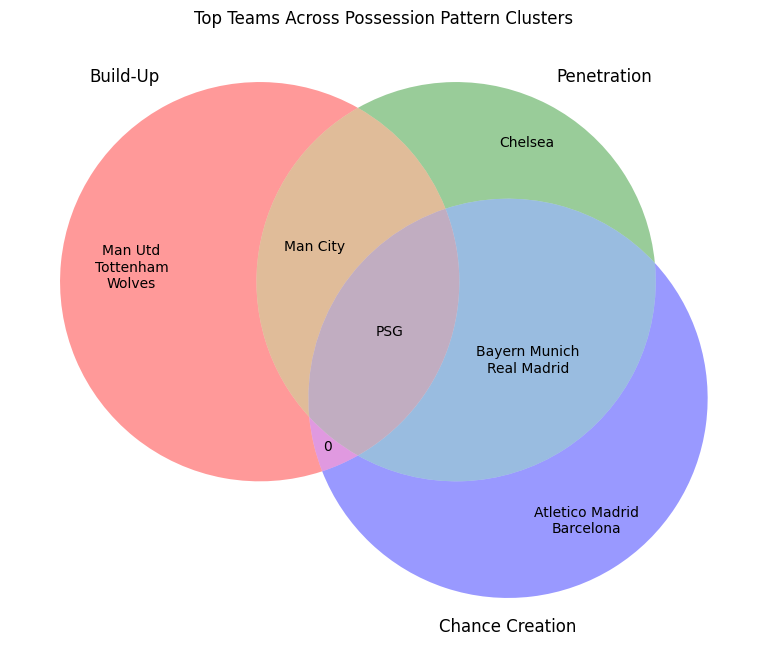

In [175]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Build sets
top_n = 5

top_teams_multi = (
    team_cluster_totals
    .sort_values(['cluster', 'Total_xPV'], ascending=[True, False])
    .groupby('cluster')
    .head(top_n)
)

set_build_up = set(top_teams_multi.loc[top_teams_multi['cluster'] == 'Build‑Up', 'teamName'])
set_penetration = set(top_teams_multi.loc[top_teams_multi['cluster'] == 'Penetration', 'teamName'])
set_chance_creation = set(top_teams_multi.loc[top_teams_multi['cluster'] == 'Chance Creation', 'teamName'])

# Create Venn diagram
plt.figure(figsize=(12, 8))
venn = venn3(
    [set_build_up, set_penetration, set_chance_creation],
    set_labels=('Build‑Up', 'Penetration', 'Chance Creation')
)
plt.title("Top Teams Across Possession Pattern Clusters")

# Define region codes and corresponding sets
region_sets = {
    '100': set_build_up - set_penetration - set_chance_creation,
    '010': set_penetration - set_build_up - set_chance_creation,
    '001': set_chance_creation - set_build_up - set_penetration,
    '110': set_build_up & set_penetration - set_chance_creation,
    '101': set_build_up & set_chance_creation - set_penetration,
    '011': set_penetration & set_chance_creation - set_build_up,
    '111': set_build_up & set_penetration & set_chance_creation
}

# Add team names to each region
for region_code, teams in region_sets.items():
    label = venn.get_label_by_id(region_code)
    if label and teams:
        label.set_text('\n'.join(sorted(teams)))


plt.savefig(f'{plot_path}/EPV/PossPatterns.png',dpi=500,bbox_inches = 'tight',facecolor=background)


In [176]:
poss_df['type'].unique()

array(['End', 'FormationSet', 'KeeperPickup', 'Pass', 'BallTouch',
       'Aerial', 'Claim', 'BallRecovery', 'Foul', 'SavedShot',
       'CornerAwarded', 'MissedShots', 'TakeOn', 'OffsidePass',
       'OffsideGiven', 'Interception', 'Save', 'Tackle', 'Goal',
       'Dispossessed', 'Clearance', 'Start', 'OffsideProvoked',
       'ShieldBallOpp', 'SubstitutionOff', 'SubstitutionOn',
       'FormationChange', 'BlockedPass', 'Card', 'KeeperSweeper',
       'Challenge', 'ShotOnPost', 'Error', 'Smother', 'Punch',
       'PenaltyFaced', 'ChanceMissed', 'GoodSkill', 'CrossNotClaimed'],
      dtype=object)

In [183]:
# Step 1: Filter only defensive actions that result in turnovers
def_events = poss_df[poss_df['type'].isin(['BallRecovery', 'Interception', 'Tackle','Clearance','BlockedPass'])]

# Step 2: Only keep successful ones (e.g., won duels, successful tackles)
successful_def = def_events[def_events['outcomeType'].isin(['Won', 'Successful'])]

# Step 3: Calculate EPV at defensive action location — assumed to be where the opponent lost the ball
successful_def["defensive_epv"] = successful_def.apply(lambda row: get_epv_value(row["x"], row["y"]), axis=1)

# Step 4: Merge with total minutes to get per 90 values
successful_def = successful_def.merge(total_minutes_played, on="playerName", how="left")
successful_def = successful_def[successful_def['TotalMinutesPlayed'] > 2000].copy()

# Step 5: Aggregate per player
def_epv_players = (
    successful_def.groupby("playerName")["defensive_epv"]
    .sum()
    .reset_index()
)

def_epv_players["def_epv_per90"] = 90 * def_epv_players["defensive_epv"] / successful_def.groupby("playerName")["TotalMinutesPlayed"].first().values

# Optional: count successful defensive actions per 90
def_counts = successful_def.groupby("playerName").size().reset_index(name="def_actions")
def_counts["def_actions_per90"] = 90 * def_counts["def_actions"] / successful_def.groupby("playerName")["TotalMinutesPlayed"].first().values

# Merge both metrics
defensive_summary = def_epv_players.merge(def_counts, on="playerName")

# Sort by defensive_epv
defensive_summary = defensive_summary.sort_values("def_epv_per90", ascending=False)

defensive_summary = defensive_summary.merge(total_minutes_played, on="playerName", how="left")


/var/folders/1p/x285c99d20ggyt7j19j59bdm0000gn/T/ipykernel_53012/1248746142.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  successful_def["defensive_epv"] = successful_def.apply(lambda row: get_epv_value(row["x"], row["y"]), axis=1)


In [184]:
defensive_summary.columns

Index(['playerName', 'defensive_epv', 'def_epv_per90', 'def_actions',
       'def_actions_per90', 'TotalMinutesPlayed'],
      dtype='object')

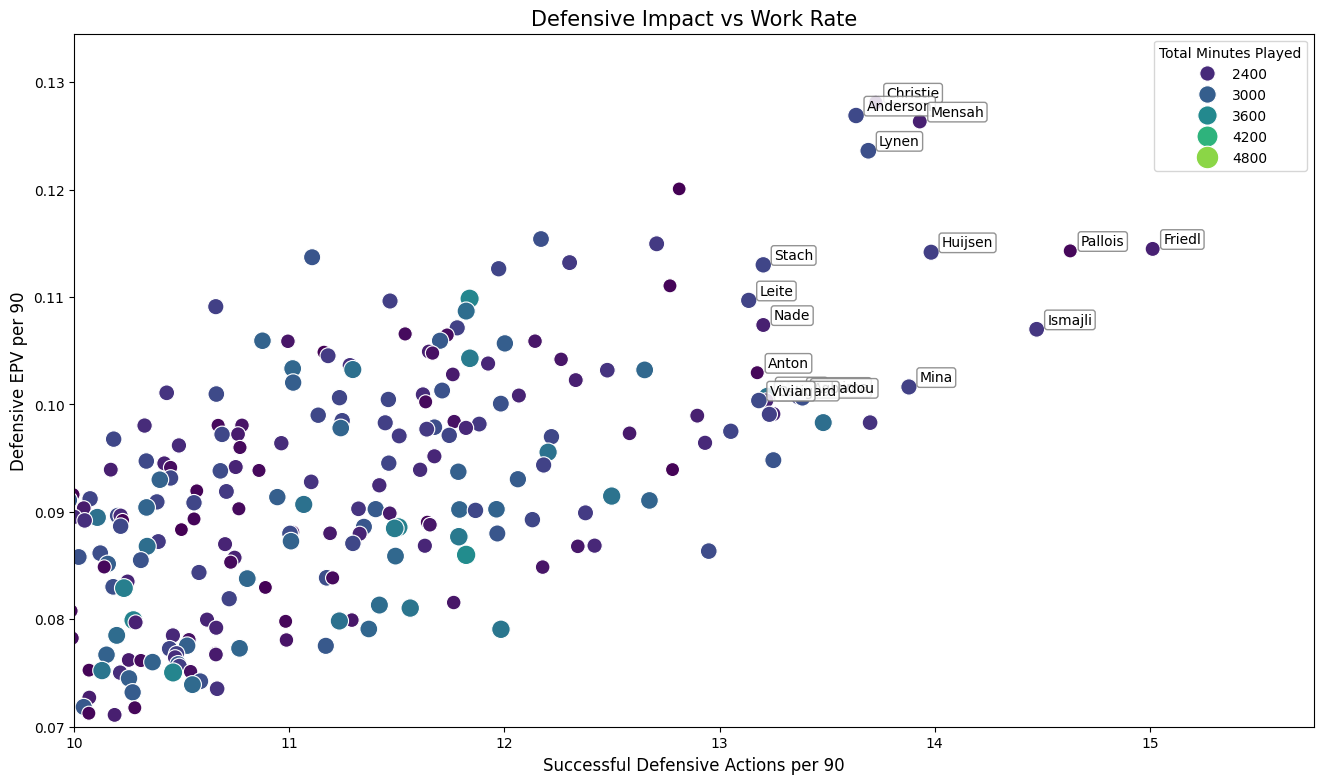

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot
plt.figure(figsize=(16, 9))
scatter = sns.scatterplot(
    data=defensive_summary,
    x="def_actions_per90",
    y="def_epv_per90",
    hue="TotalMinutesPlayed",
    size="TotalMinutesPlayed",
    palette="viridis",
    sizes=(100, 300),
    legend="brief"
)

# Add player labels to the points
for _, row in defensive_summary.iterrows():
    name = row.get('playerName', str(_))
    last = name.split(' ')[-1] if ' ' in name else name
    if row['def_epv_per90'] > 0.1 and row['def_actions_per90'] > 13:
        plt.text(row["def_actions_per90"] + 0.05,row["def_epv_per90"]+0.0005,last,
            fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.85))

plt.xlim(10, defensive_summary['def_actions_per90'].max() * 1.05)
plt.ylim(0.07, defensive_summary['def_epv_per90'].max() * 1.05)

plt.xlabel("Successful Defensive Actions per 90",fontsize=12)
plt.ylabel("Defensive EPV per 90",fontsize=12)
plt.title("Defensive Impact vs Work Rate",fontsize=15)
plt.grid(False)
plt.legend(title="Total Minutes Played", loc='best')


plt.savefig(f'{plot_path}/EPV/DefEPV.png',dpi=500,bbox_inches = 'tight',facecolor=background)


In [11]:
carries = team_df[team_df['type'] == 'Carry']

In [12]:
carries.shape

(0, 286)

In [15]:
player_pv.head()

,pv_progressive,pv_regressive,pv_loss,pv_loss_direct,dynamic_epv,minutesPlayed,progressive_action,pv_progressive_per90,pv_regressive_per90,pv_loss_per90,pv_loss_direct_per90,net_pv_per90,pv_per_prog_action,passes_per_90
playerName,,,,,,,,,,,,,,
Abdoulaye Toure,4.895488,107.010043,3.022211,0.359842,111.905531,2344.0,47,0.187967,4.108747,0.116041,0.013816,-4.050638,0.104159,31.753413
Achraf Hakimi,12.584913,173.990000,3.529797,1.771545,186.574913,2072.0,116,0.546642,7.557481,0.153321,0.076949,-7.241109,0.108491,74.623552
Adrien Rabiot,5.337886,139.213865,4.869436,1.751436,144.551751,2542.0,48,0.188989,4.928894,0.172403,0.062010,-4.974318,0.111206,44.610543
Adrien Thomasson,6.646677,154.209249,6.094122,2.313002,160.855927,2629.0,60,0.227539,5.279130,0.208623,0.079182,-5.339396,0.110778,42.073032
Adrien Truffert,8.465793,142.253174,3.862264,1.442773,150.718967,2805.0,77,0.271630,4.564273,0.123923,0.046292,-4.462858,0.109945,32.310160


In [31]:
top_players = player_pv.sort_values(by=['net_pv_per90'],axis=0,ascending=False).head()

In [32]:
top_players

,pv_progressive,pv_regressive,pv_loss,pv_loss_direct,dynamic_epv,minutesPlayed,progressive_action,pv_progressive_per90,pv_regressive_per90,pv_loss_per90,pv_loss_direct_per90,net_pv_per90,pv_per_prog_action,passes_per_90
playerName,,,,,,,,,,,,,,
Beraldo,170.663858,15.718958,0.757831,-0.009600,186.382817,2089.0,2160,7.352679,0.677217,0.032650,-0.000414,6.643227,0.079011,88.104356
Pierre-Emile Hojbjerg,224.230536,19.786949,3.391156,0.669793,244.017485,2722.0,2876,7.413941,0.654234,0.112125,0.022146,6.625436,0.077966,85.503306
Vitinha,174.580479,18.628163,2.752610,0.513504,193.208642,2080.0,2218,7.553963,0.806026,0.119103,0.022219,6.606615,0.078711,93.807692
Leonardo Balerdi,196.364412,19.031697,1.734949,0.062112,215.396109,2419.0,2529,7.305828,0.708083,0.064550,0.002311,6.530884,0.077645,85.944605
Achraf Hakimi,169.381794,17.193119,3.529797,1.771545,186.574913,2072.0,2159,7.357317,0.746805,0.153321,0.076949,6.380241,0.078454,74.623552
